# Classifier for GWs with memory using ML technics

This notebook aims to classify GWs waveforms with and without memory effect using machine learning techniques. We will generate synthetic waveforms using the `pycbc` library, including the memory effect with the `gwmemory` package, and then train a simple classifier to distinguish between the two classes of waveforms.

Then, to be more realistic, we will add noise to the waveforms and evaluate the performance of the classifier in this case. In order to to improve the associated scores, we will also apply some preprocessing techniques to the data (both ML technics and signal processing technics). 

The possibility of detection and the SNR will be also discussed for the case of different current and future detectors (LIGO, Virgo, KAGRA, Einstein Telescope, Cosmic Explorer, LISA).

## Import libraries

In [1]:
%pip install pycbc

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score
import gwmemory
import warnings
from pycbc.waveform import get_td_waveform

warnings.filterwarnings('ignore')

# 1. Perfect case : no noise, no preprocessing (only in temporal domain)

For simplicity, we will start with a perfect case where we generate waveforms without noise and without any preprocessing. We can directly use the raw waveforms in the temporal domain to train our classifier and evaluate its performance.

First we will generate a dataset of waveforms with and without memory effect . We will create two classes of waveforms: 
- **Class 0**: waveforms *without* memory effect

- **Class 1**: waveforms *with* memory effect

We resterict ourselves to a simple binary classification problem, but in practice, we could also consider more complex scenarios with multiple classes (e.g., different types of sources, different parameters, etc.).

To accuratly sum the waveforms with the associated memory effect, we center the waveforms on the merger time, which is the time when the amplitude of the waveform reaches its maximum (t = 0 : merger time). This way, we can ensure that the memory effect is properly aligned with the main signal, and we can accurately sum the two components to create the final waveform with memory effect in the same interpolated time array ([-0.08 ; 0.02]s ).

**TO DO NEXT :**
- Check if there is a difference if we *only keep the final memory effect* (while the memory is build up during inspiral + merger + ringdown).
    - *Advantage*: less data to process, and more focused on the memory effect itself
    - *Disadvantage*: lose some information about the build up of the memory effect during the inspiral and merger phases, which could be useful for classification.

In [ ]:
def generate_mixed_waveforms(n_samples=100, model="IMRPhenomD", params=None, plot_ditrib=False):
    """
    Generete a dataset of gravitational waveforms with and without memory effects.
    Parameters:
- n_samples: Total number of waveforms to generate (half with memory, half without).
- model: The waveform model to use for generating the memory effect (e.g., "IMRPhenomD").
- params: A dictionary of parameters for waveform generation (e.g., delta_t, f_lower, t_c).
Returns:
- X: A numpy array of shape (n_samples, n_time_points) containing the waveforms.
- y: A numpy array of shape (n_samples,) containing the labels (1 for waveforms with memory, 0 for waveforms without memory).
    """
    # Fixed parameters - should add this to params if we want to vary them
    phase = 0
    q = 1.0
    spin_1 = [0.0, 0.0, 0.0]
    spin_2 = [0.0, 0.0, 0.0]
    times = np.linspace(-0.08, 0.02, 10001)
    # Init the features and labels
    X = []
    y = []
    # Randomly sample the parameters that we want to vary (mass1, mass2, distance, inclination)
    np.random.seed(42) # for reproducibility
    mass1 = np.random.uniform(20, 40, size=n_samples )
    mass2 = np.random.uniform(20, 40, size=n_samples)
    distance = np.random.uniform(300, 600, size=n_samples)
    inclination = np.random.uniform(0, np.pi, size=n_samples)
    random_param ={
        "mass1": mass1,
        "mass2": mass2,
        "distance": distance,
        "inclination": inclination
    }
    if plot_ditrib:
        # Plot the distribution of the parameters to check that they are well sampled
        fig, axs = plt.subplots(2, 2, figsize=(12, 10))
        for i, key in enumerate(random_param.keys()):
            axs[i//2, i%2].hist(random_param[key], bins=20, alpha=0.7, color='blue', edgecolor='black', linewidth=1.2)
            axs[i//2, i%2].set_title(f"Distribution of {key}")
        plt.tight_layout()
        plt.show()
    for i in range(n_samples):

        # Sans mémoire (PyCBC)
        hp, _ = get_td_waveform(
            approximant=model,
            mass1=random_param['mass1'][i],
            mass2=random_param['mass2'][i],
            delta_t=params['delta_t'],
            f_lower=params['f_lower'],
            inclination=random_param['inclination'][i],
            distance=random_param['distance'][i],
        )
        t = hp.sample_times.numpy()
        hp_arr = hp.numpy()

        # Alignement sur le merger (maximum d'amplitude)
        merger_idx = np.argmax(np.abs(hp_arr))
        t_merger = t[merger_idx]
        # Recentrer le temps autour du merger
        t_aligned = t - t_merger

        # Interpolation sur la grille commune (-0.08 à 0.02)
        hp_interp = np.interp(times, t_aligned, hp_arr)
        t_interp = np.interp(times, t_aligned, t_aligned)
        if i < n_samples // 2:
            # Avec mémoire (gwmemory)
            total_mass = random_param['mass1'][i] + random_param['mass2'][i]
            parameters = dict(
                total_mass=total_mass,
                distance=random_param['distance'][i],
                model=model,
                inc=random_param['inclination'][i],
                phase=phase,
                times=times,
                q=q,
                spin_1=spin_1,
                spin_2=spin_2,
                t_c=params['t_c']
            )
            h_mem, _ = gwmemory.time_domain_memory(**parameters)
            h_tot = hp_interp + h_mem['plus']
            X.append(h_tot)
            y.append(1)
        else:
            X.append(hp_interp)
            y.append(0)
    return np.array(X), np.array(y), t_interp

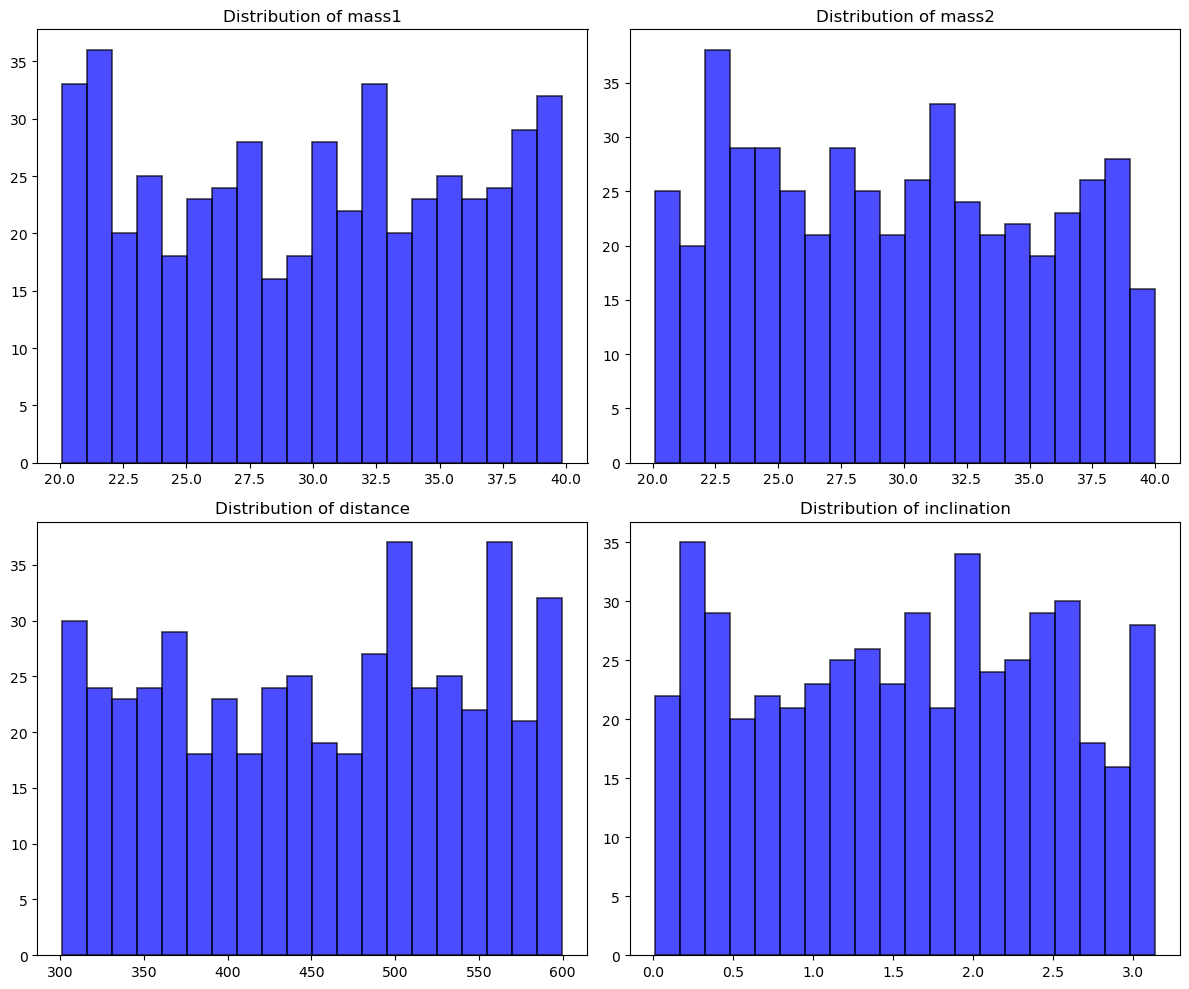

Shape of X: (500, 10001), Shape of y: (500,), Shape of t: (10001,)


In [4]:
params = {
    'delta_t': 1.0 / 4096,
    'f_lower': 20.0,
    't_c' : 0.0
}
n_samples = 500
X, y, t = generate_mixed_waveforms(n_samples, model="IMRPhenomD", params=params, plot_ditrib=True)
print(f"Shape of X: {X.shape}, Shape of y: {y.shape}, Shape of t: {t.shape}")
# Save samples for later use (in txt files)
np.savetxt("X_samples_perfect.txt", X)
np.savetxt("y_samples_perfect.txt", y)
np.savetxt("t_samples_perfect.txt", t)

### Plots of signals
We can plot some examples of waveforms with and without memory effect to visualize the differences between the two classes. In this way, we can see how the memory effect modifies the shape of the waveform and how it can be used to distinguish between the two classes (and so if the model is able to learn these differences). 


**TO DO NEXT** : We can also plot the associated PSD - spectrograms to see how the frequency content of the signals differs between the two classes.

In [4]:
X = np.loadtxt("X_samples_perfect.txt")
y = np.loadtxt("y_samples_perfect.txt")
t = np.loadtxt("t_samples_perfect.txt")

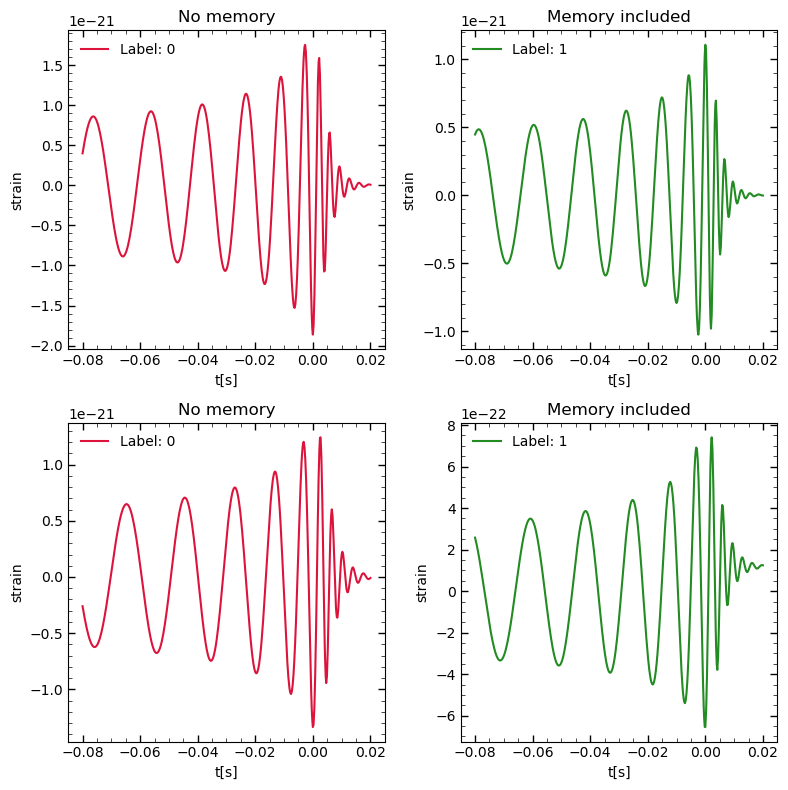

In [23]:
# Affichage de quelques exemples randoms
random_indices = np.random.choice(len(X), 4, replace=False)
plt.figure(figsize=(8, 8), constrained_layout=True)
for i, idx_r in enumerate(random_indices):
    plt.subplot(2, 2, i+1)
    plt.plot(t, X[idx_r], label=f"Label: {y[idx_r]:.0f}", color='forestgreen' if y[idx_r] == 1 else 'crimson')
    plt.title(f"{'Memory included' if y[idx_r] == 1 else 'No memory'}")
    plt.xlabel("t[s]")
    plt.ylabel("strain")
    plt.minorticks_on()
    plt.tick_params(axis='both', which='major', direction='in', length=5, width=1, top=True, right=True)
    plt.tick_params(axis='both', which='minor', direction='in', length=3, width=0.5, top=True, right=True)
    plt.legend(loc = 'upper left', frameon=False)
plt.tight_layout()
plt.show()

### Prepare the data for training and testing
We will split our dataset into a training set and a test set. The training set will be used to train the classifier, while the test set will be used to evaluate its performance. We can use a simple 80/20 split, where 80% of the data is used for training and 20% for testing.

**TO DO NEXT :** We can also use cross-validation techniques to further evaluate the performance of the classifier and to tune its hyperparameters.

In [6]:
# Training et test set
X = X.reshape(X.shape[0], -1)  # Aplatir les waveforms
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2, random_state=42,
                                                    shuffle=True, stratify=y)

# Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


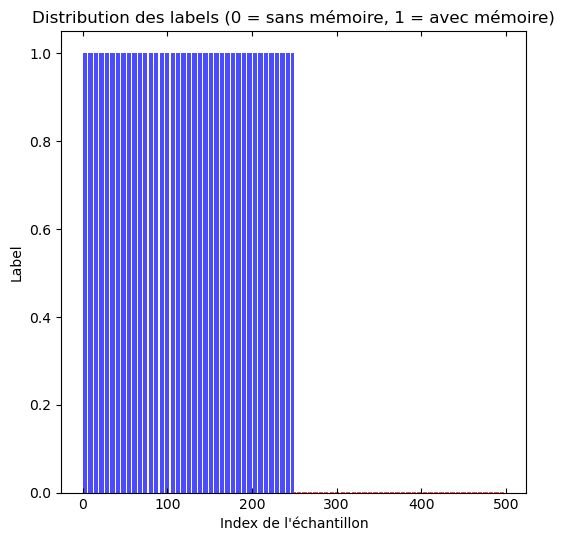

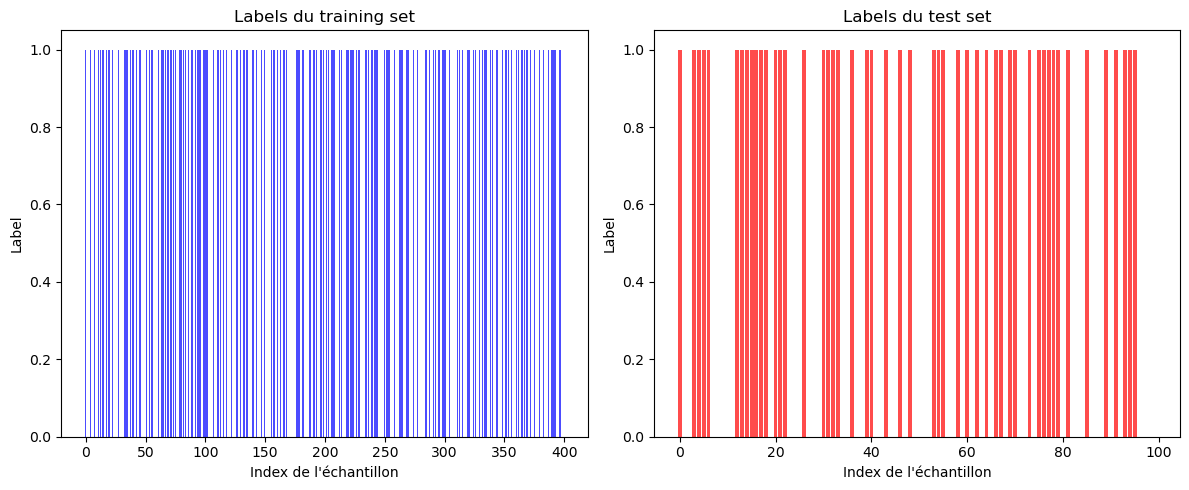

In [7]:
# plot comment y est répartie (avant shuffle)
plt.figure(figsize=(6, 6))
plt.bar(range(len(y)), y +0.001,  color=['red' if label == 0 else 'blue' for label in y], alpha=0.7)
plt.title("Distribution des labels (0 = sans mémoire, 1 = avec mémoire)")
plt.xlabel("Index de l'échantillon")
plt.ylabel("Label")
plt.grid(False)
plt.tick_params(axis='x', which='both', bottom=True, top=True, direction='in')
plt.show()
# Plot de y_test et y_train
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(range(len(y_train)), y_train, color='blue', alpha=0.7)
plt.title("Labels du training set")
plt.xlabel("Index de l'échantillon")
plt.ylabel("Label")
plt.grid(False)
plt.subplot(1, 2, 2)
plt.bar(range(len(y_test)), y_test, color='red', alpha=0.7)
plt.title("Labels du test set")
plt.xlabel("Index de l'échantillon")
plt.ylabel("Label")
plt.grid(False)
plt.tight_layout()
plt.show()

### Classifiers and performance evaluation
We will start with simple classifiers and visualize their performance using learning curves, confusion matrices, and precision-recall curves. We can also compare the performance of different classifiers to see which one performs best on our dataset.

A function to plot the evolution of the performance of the classifier as a function of a specific parameter (e.g., inclination) will be also implemented. This will allow us to see how the performance of the classifier changes as we vary this parameter, and to identify any trends or patterns in the data.

TO DO NEXT : Implement **more complex classifiers** (e.g., CNN, wavelet,...) and compare their performance to the simpler ones.

In [8]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, X, y, cv=5, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 10), random_state=42, info_title=""):
    """
    Plot the learning curve of a given estimator for a given scoring metric.
    Parameters:
- estimator: The machine learning model to evaluate (e.g., SVC()).
- X: The feature matrix (training data).
- y: The target vector (labels).
- cv: The number of cross-validation folds (default is 5).
- scoring: The scoring metric to use for evaluation (default is 'accuracy').
- train_sizes: An array of training set sizes to use for generating the learning curve (default is np.linspace(0.1, 1.0, 10)).
- random_state: The random seed for reproducibility (default is 42).
Returns:
- A plot of the learning curve showing training and cross-validation scores as a function of the training set size.
    """
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, scoring=scoring, train_sizes=train_sizes, shuffle=True,random_state=random_state
    )
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.figure(figsize=(8, 6))
    plt.title("Learning Curve for metric: " + scoring + " \n " + info_title)
    plt.xlabel("Training examples")
    plt.ylabel(scoring.capitalize())
    plt.grid(ls='--', alpha=0.5)
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.2, color="blue")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.2, color="orange")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="blue", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="orange", label="Cross-validation score")
    plt.legend(loc="best")
    plt.tick_params(axis='both', which='major', labelsize=8, direction='in', length=6, width=1, top=True, right=True)
    plt.tight_layout()
    plt.show()

In [9]:
def plot_precision_recall_curves(y_true, y_score, class_names=None, classifier_name=""):
    """
    Plot precision-recall curves for binary classification.
    Parameters:
- y_true: True binary labels (shape: [n_samples]).
- y_score: Predicted probabilities for the positive class (shape: [n_samples, 2] or [n_samples,]).
- class_names: Optional list of class names for labeling the curves.    
    Returns:
- A plot of precision-recall curves for each class and the micro-average.
    Remark : 
    Highly inspired by the sklearn example : https://scikit-learn.org/stable/auto_examples/model_selection/plot_precision_recall.html
    """
    from sklearn.metrics import PrecisionRecallDisplay, precision_recall_curve, average_precision_score
    from sklearn.preprocessing import label_binarize
    from itertools import cycle

    # Forcer la binarisation sur les deux classes
    y_true_bin = label_binarize(y_true, classes=[0, 1])
    n_classes = y_true_bin.shape[1]

    precision = dict()
    recall = dict()
    average_precision = dict()
    for i in range(n_classes):
        precision[i], recall[i], _ = precision_recall_curve(y_true_bin[:, i], y_score[:, i])
        average_precision[i] = average_precision_score(y_true_bin[:, i], y_score[:, i])

    # Micro-average (corrigé pour le cas binaire)
    precision["micro"], recall["micro"], _ = precision_recall_curve(
        y_true, y_score[:, 1]
    )
    average_precision["micro"] = average_precision_score(y_true, y_score[:, 1])

    # Plot
    colors = cycle(["#d1495b", "#00798c"])
    fig, ax = plt.subplots(figsize=(8, 7))

    # Courbes iso-f1
    f_scores = np.linspace(0.2, 0.8, num=4)
    for f_score in f_scores:
        x = np.linspace(0.01, 1)
        y = f_score * x / (2 * x - f_score)
        (l,) = ax.plot(x[y >= 0], y[y >= 0], color="#edae49", alpha=0.2)
        ax.annotate(f"f1={f_score:0.1f}", xy=(0.9, y[45] + 0.02))

    # Micro-average
    display = PrecisionRecallDisplay(
        recall=recall["micro"],
        precision=precision["micro"],
        average_precision=average_precision["micro"],
    )
    display.plot(ax=ax, name="Micro-average", color="gold")

    # Par classe
    for i, color in zip(range(n_classes), colors):
        name = f"Classe {i}" if class_names is None else class_names[i]
        display = PrecisionRecallDisplay(
            recall=recall[i],
            precision=precision[i],
            average_precision=average_precision[i],
        )
        display.plot(ax=ax, name=f"Precision-recall {name}", color=color, despine=True)

    # Légende iso-f1
    handles, labels = display.ax_.get_legend_handles_labels()
    handles.extend([l])
    labels.extend(["iso-f1 curves"])
    ax.legend(handles=handles, labels=labels, loc="best")
    ax.set_title("Precision-Recall curve with iso-f1 curves" + '\n' + f"{classifier_name}")
    plt.show()


In [10]:
def plot_performance_vs_param(param_name, param_range, fixed_params, model, classifier, n_samples=50, info_title=""):
    """
    Trace la performance du classifieur en fonction d'un paramètre (ex: masse m1).
    param_name : str, nom du paramètre à faire varier (ex: 'mass1')
    param_range : array, valeurs du paramètre à tester (ex: np.linspace(20, 40, 10))
    fixed_params : dict, autres paramètres à garder fixes (ex: masses, distance, inclination, etc.)
    model : str, nom du modèle de waveform (ex: 'IMRPhenomD')
    classifier : sklearn classifier (déjà instancié)
    n_samples : int, nombre d'échantillons par valeur de paramètre
    """
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import accuracy_score

    scores = []
    for val in param_range:
        # Générer les paramètres pour tous les samples
        params = fixed_params.copy()
        params[param_name] = np.full(n_samples, val)
        # Générer les autres paramètres aléatoirement si besoin
        if param_name != 'mass1':
            params['mass1'] = np.random.uniform(20, 40, n_samples)
        if param_name != 'mass2':
            params['mass2'] = np.random.uniform(20, 40, n_samples)
        if param_name != 'distance':
            params['distance'] = np.random.uniform(300, 600, n_samples)
        if param_name != 'inclination':
            params['inclination'] = np.random.uniform(0, np.pi, n_samples)
        # Générer les données (on suppose que generate_mixed_waveforms existe déjà)
        X, y, _ = generate_mixed_waveforms(
            n_samples=n_samples,
            model=model,
            params={
                'delta_t': fixed_params.get('delta_t', 1.0/4096),
                'f_lower': fixed_params.get('f_lower', 20.0),
                't_c': fixed_params.get('t_c', 0.0)
            }
        )
        X = X.reshape(X.shape[0], -1)
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        classifier.fit(X_train_scaled, y_train)
        y_pred = classifier.predict(X_test_scaled)
        acc = accuracy_score(y_test, y_pred)
        scores.append(acc)
    plt.figure(figsize=(7, 5))
    plt.plot(param_range, scores, marker='o')
    plt.xlabel(param_name)
    plt.ylabel('Accuracy')
    plt.title(f'Classifier accuracy vs {param_name}'+ '\n' + info_title)
    plt.grid(ls='--', alpha=0.5)
    plt.tick_params(axis='both', which='major', labelsize=8, direction='in', length=6, width=1, top=True, right=True)
    plt.tight_layout()
    plt.show()

In [11]:
def plot_confusion_matrices(y_true, y_pred, class_names, title):
    import matplotlib.pyplot as plt
    from sklearn.metrics import ConfusionMatrixDisplay

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Non normalisée
    disp = ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        display_labels=class_names,
        cmap=plt.cm.Greens,
        normalize=None,
        ax=axes[0]
    )
    axes[0].set_title("Confusion matrix\n" + f"{title}")
    axes[0].grid(False)

    # Normalisée
    disp_norm = ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        display_labels=class_names,
        cmap=plt.cm.Greens,
        normalize='true',
        ax=axes[1]
    )
    axes[1].set_title("Normalised confusion matrix\n" + f"{title}")
    axes[1].grid(False)

    plt.tight_layout()
    plt.show()

In [ ]:
# Entrainement sur plusieurs classsifieurs
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

classifiers = {
    "SVM (linéaire)": SVC(kernel="linear", probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, criterion = 'log_loss',random_state=42, max_depth=5, min_samples_leaf=5, n_jobs=-1),
}
y_pred_dict = {}
proba_dict = {}
for name, clf in classifiers.items():
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)
    y_pred_dict[name] = y_pred
    proba_dict[name] = clf.predict_proba(X_test_scaled)
    # Compute precision - recall - f1-score
    print(f"Classification report for {name}:\n")
    print(classification_report(y_test, y_pred, target_names=["No memory", "Memory included"]))
    print("\n")


In [13]:
#for name, clf in classifiers.items():
#    y_pred = y_pred_dict[name]
#    plot_learning_curve(clf, X_train_scaled, y_train, cv=5, scoring='accuracy', random_state=42, info_title=name)

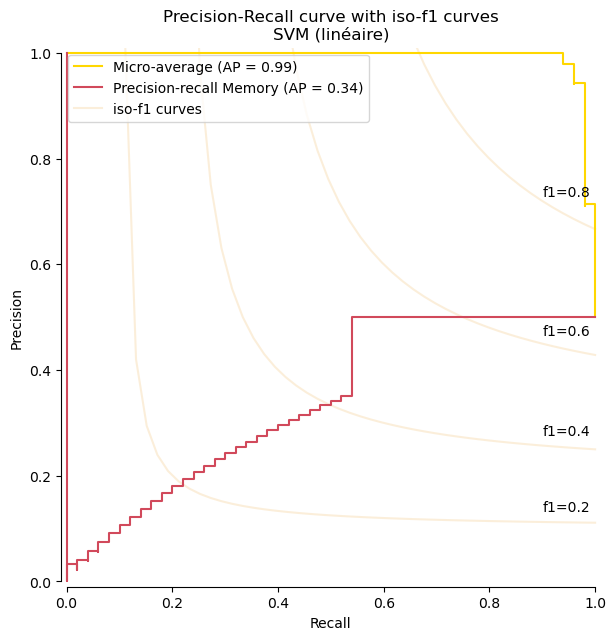

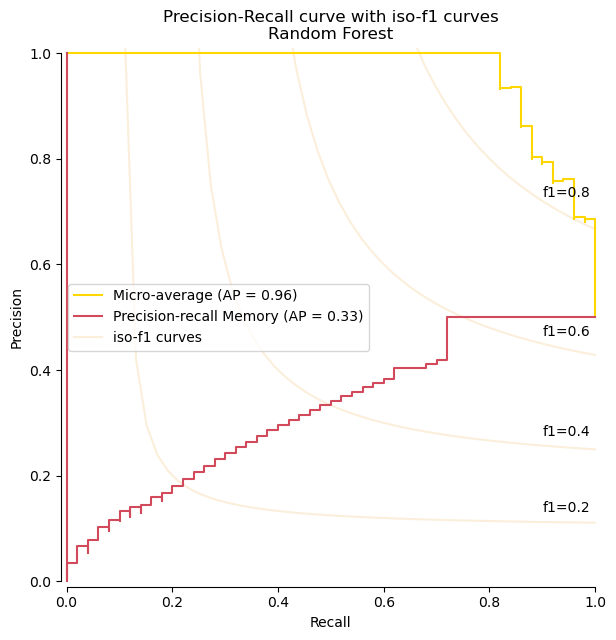

In [14]:
for name, clf in classifiers.items():
    plot_precision_recall_curves(y_test, proba_dict[name], class_names=['Memory', 'No Memory'], classifier_name=name)

In [15]:
#param_range = np.linspace(0, np.pi, 20)
#fixed_params = {'mass1' : 30, 'mass2': 30, 'distance': 100, 'delta_t': 1.0/4096, 'f_lower': 20.0, 't_c': 0.0}
 # Test only with one classifier to save time
#plot_performance_vs_param('inclination', param_range, fixed_params, model='IMRPhenomD', classifier=classifiers['Random Forest'], n_samples=25, info_title='Random Forest')

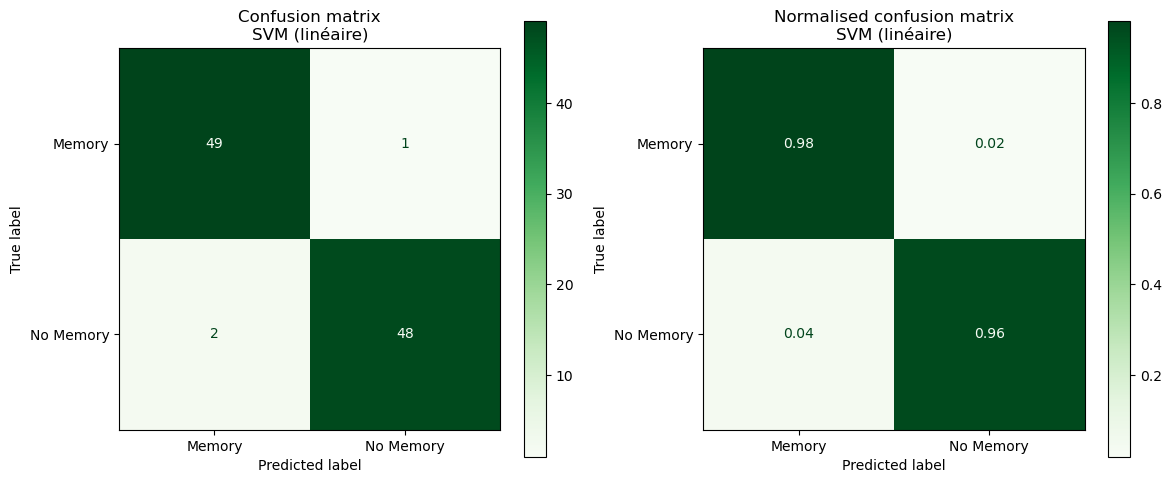

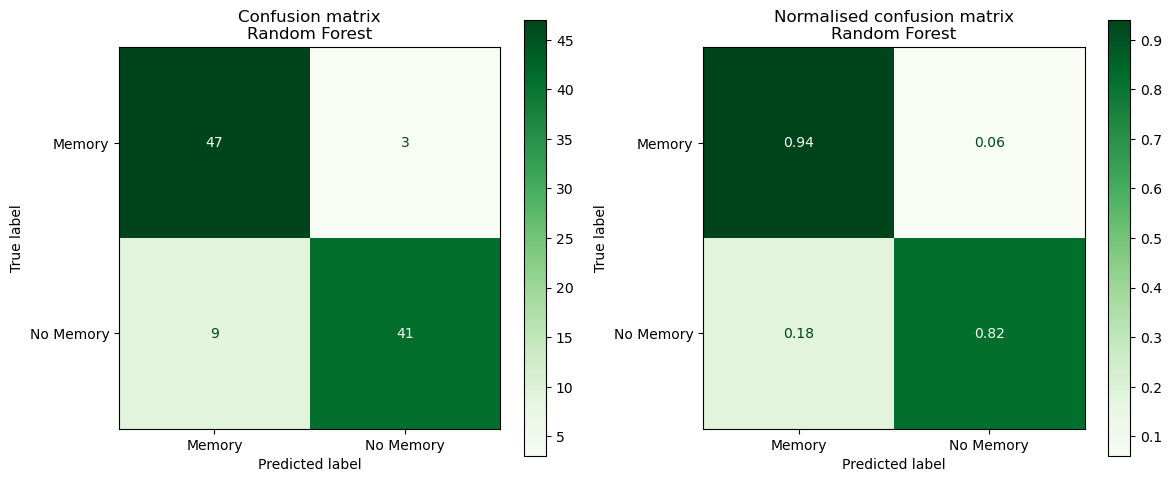

In [16]:
for name, clf in classifiers.items():
    y_pred = y_pred_dict[name]
    plot_confusion_matrices(y_test, y_pred, class_names=["Memory", "No Memory"], title=name)

---

# 2. More realistic case : with noise, with preprocessing (both ML technics and signal processing technics)

## 2.1. Gaussian noise addition
To make our classification task more realistic, we will add Gaussian noise to the waveforms. This will simulate the noise present in real gravitational wave detectors and make the classification task more challenging. We will define a signal-to-noise ratio (SNR) and add noise accordingly to achieve the desired SNR level

In [ ]:
def add_gaussian_noise(signal):
    """
    Add Gaussian noise to a signal.
    Parameters:
- signal: The input signal (numpy array).
- sigma: The standard deviation of the Gaussian noise
Returns:
- The signal with added Gaussian noise
    """
    sigma = np.mean(np.abs(signal)) * 1  # Adjust sigma based on the signal amplitude
    print(sigma)
    np.random.seed(42)  # For reproducibility
    noise = np.random.normal(0, sigma, size=len(signal))
    return signal + noise

In [18]:
def generate_mixed_waveforms_noise(n_samples=100, model="IMRPhenomD", params=None):
    """
    Generete a dataset of gravitational waveforms with and without memory effects.
    Parameters:
- n_samples: Total number of waveforms to generate (half with memory, half without).
- model: The waveform model to use for generating the memory effect (e.g., "IMRPhenomD").
- params: A dictionary of parameters for waveform generation (e.g., delta_t, f_lower, t_c).
Returns:
- X: A numpy array of shape (n_samples, n_time_points) containing the waveforms.
- y: A numpy array of shape (n_samples,) containing the labels (1 for waveforms with memory, 0 for waveforms without memory).
    """
    # Fixed parameters - should add this to params if we want to vary them
    phase = 0

    spin_1 = [0.0, 0.0, 0.0]
    spin_2 = [0.0, 0.0, 0.0]
    times = np.linspace(-0.08, 0.02, 10001)
    # Init the features and labels
    X = []
    y = []
    # Randomly sample the parameters that we want to vary (mass1, mass2, distance, inclination)
    np.random.seed(42) # for reproducibility
    mass1 = np.random.uniform(20, 40, size=n_samples, )
    mass2 = np.random.uniform(20, 40, size=n_samples)
    distance = np.random.uniform(300, 600, size=n_samples)
    inclination = np.random.uniform(0, np.pi, size=n_samples)
    random_param ={
        "mass1": mass1,
        "mass2": mass2,
        "distance": distance,
        "inclination": inclination
    }
    # Plot the distribution of the parameters to check that they are well sampled
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    for i, key in enumerate(random_param.keys()):
        axs[i//2, i%2].hist(random_param[key], bins=20, alpha=0.7, color='blue', edgecolor='black', linewidth=1.2)
        axs[i//2, i%2].set_title(f"Distribution of {key}")
    plt.tight_layout()
    plt.show()
    for i in range(n_samples):

        # Sans mémoire (PyCBC)
        hp, _ = get_td_waveform(
            approximant=model,
            mass1=random_param['mass1'][i],
            mass2=random_param['mass2'][i],
            delta_t=params['delta_t'],
            f_lower=params['f_lower'],
            inclination=random_param['inclination'][i],
            distance=random_param['distance'][i],
        )
        t = hp.sample_times.numpy()
        hp_arr = hp.numpy()

        # Alignement sur le merger (maximum d'amplitude)
        merger_idx = np.argmax(np.abs(hp_arr))
        t_merger = t[merger_idx]
        # Recentrer le temps autour du merger
        t_aligned = t - t_merger

        # Interpolation sur la grille commune (-0.08 à 0.02)
        hp_interp = np.interp(times, t_aligned, hp_arr)
        t_interp = np.interp(times, t_aligned, t_aligned)
        # Add Gaussian noise to the interpolated waveform
        hp_interp = add_gaussian_noise(hp_interp)
        if i < n_samples // 2:
            # Avec mémoire (gwmemory)
            total_mass = random_param['mass1'][i] + random_param['mass2'][i]
            q = random_param['mass1'][i] / random_param['mass2'][i]
            parameters = dict(
                total_mass=total_mass,
                distance=random_param['distance'][i],
                model=model,
                inc=random_param['inclination'][i],
                phase=phase,
                times=times,
                q=q,
                spin_1=spin_1,
                spin_2=spin_2,
                t_c=params['t_c']
            )
            h_mem, _ = gwmemory.time_domain_memory(**parameters)
            h_tot = hp_interp + h_mem['plus']
            X.append(h_tot)
            y.append(1)
        else:
            X.append(hp_interp)
            y.append(0)
    return np.array(X), np.array(y), t_interp

In [20]:
params = {
    'approximant': 'IMRPhenomD',
    'delta_t': 1.0 / 4096,
    'f_lower': 20.0,
    't_c' : 0.0
}

#X, y, t = generate_mixed_waveforms_noise(n_samples, model="IMRPhenomD", params=params)
# Save samples for later use (in txt files)
X = np.loadtxt("X_samples_perfect.txt")
y = np.loadtxt("y_samples_perfect.txt")
y_noise = y # We keep the same labels as before, since we are just adding noise to the waveforms, not changing their nature
t = np.loadtxt("t_samples_perfect.txt")
t_noise = t # We keep the same time array, since we are just adding noise to the waveforms, not changing their time sampling
X_noise = np.array([add_gaussian_noise(x) for x in X])
np.savetxt("X_samples_gnoise.txt", X_noise)


3.606947489788873e-22
3.249641244982619e-22
4.2146831244669497e-22
3.4161881798698784e-22
2.376843105961815e-22
2.0006705654142588e-22
2.4109701061376815e-22
2.941373441128791e-22
4.488188461383298e-22
4.935990645575025e-22
4.455925006018883e-22
3.254790883768315e-22
5.544899533974378e-22
7.584678605388779e-22
2.6731073778131136e-22
2.719655160927452e-22
3.6310373436613816e-22
5.37495341370621e-22
3.695818737303132e-22
5.780615719830553e-22
4.981652358866726e-22
4.746740815219001e-22
2.7281975204973147e-22
4.1479582146234015e-22
2.4319922491633833e-22
4.49048974249065e-22
2.514503252613245e-22
2.6097919645352854e-22
4.092381349095627e-22
2.0938754611898074e-22
6.046474601463782e-22
2.9503994826581845e-22
4.321928820530827e-22
6.20084934594973e-22
5.364188294868951e-22
5.942233969874923e-22
5.24444269037416e-22
2.2146397628839614e-22
6.658666278853747e-22
2.614607033080266e-22
3.4424896460846604e-22
4.423996130429027e-22
2.340032392257089e-22
4.529018015808267e-22
3.9343256964011827e-22

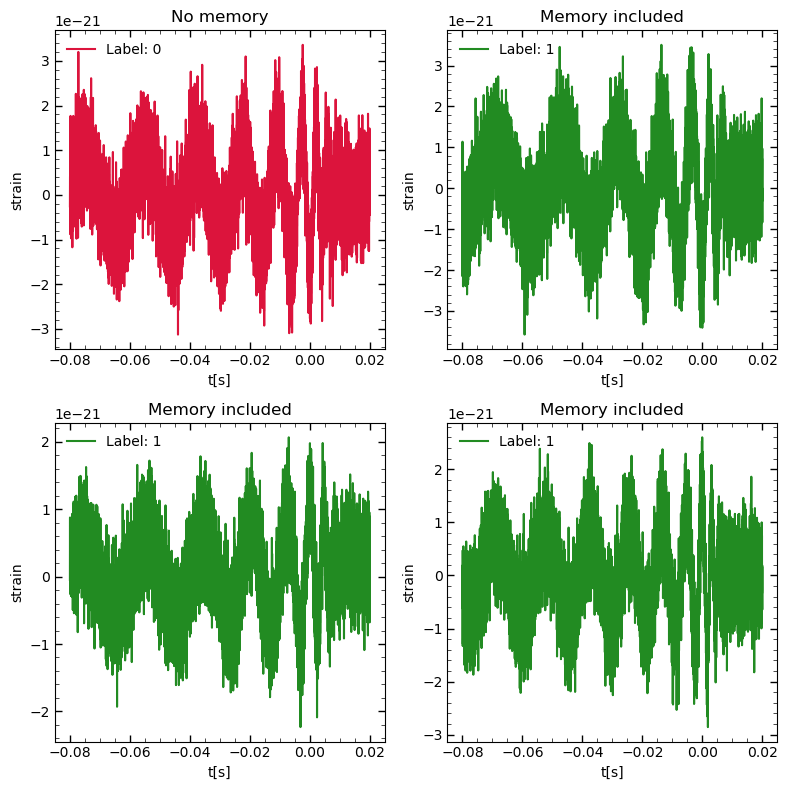

In [24]:
X = np.loadtxt("X_samples_gnoise.txt")
t = np.loadtxt("t_samples_perfect.txt")
# Affichage de quelques exemples randoms
random_indices = np.random.choice(len(X), 4, replace=False)
plt.figure(figsize=(8, 8))
for i, idx_r in enumerate(random_indices):
    plt.subplot(2, 2, i+1)
    plt.plot(t, X[idx_r], label=f"Label: {y[idx_r]:.0f}", color='forestgreen' if y[idx_r] == 1 else 'crimson')
    plt.title(f"{'Memory included' if y[idx_r] == 1 else 'No memory'}")
    plt.xlabel("t[s]")
    plt.ylabel("strain")
    plt.minorticks_on()
    plt.tick_params(axis='both', which='major', direction='in', length=5, width=1, top=True, right=True)
    plt.tick_params(axis='both', which='minor', direction='in', length=3, width=0.5, top=True, right=True)
    plt.legend(loc = 'upper left', frameon=False)
plt.tight_layout()
plt.show()

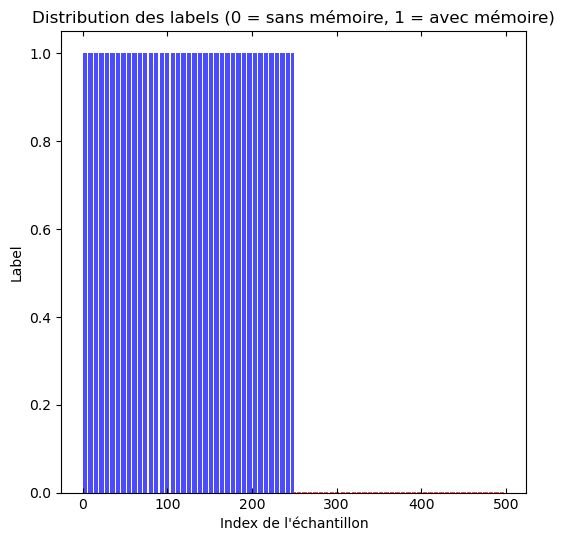

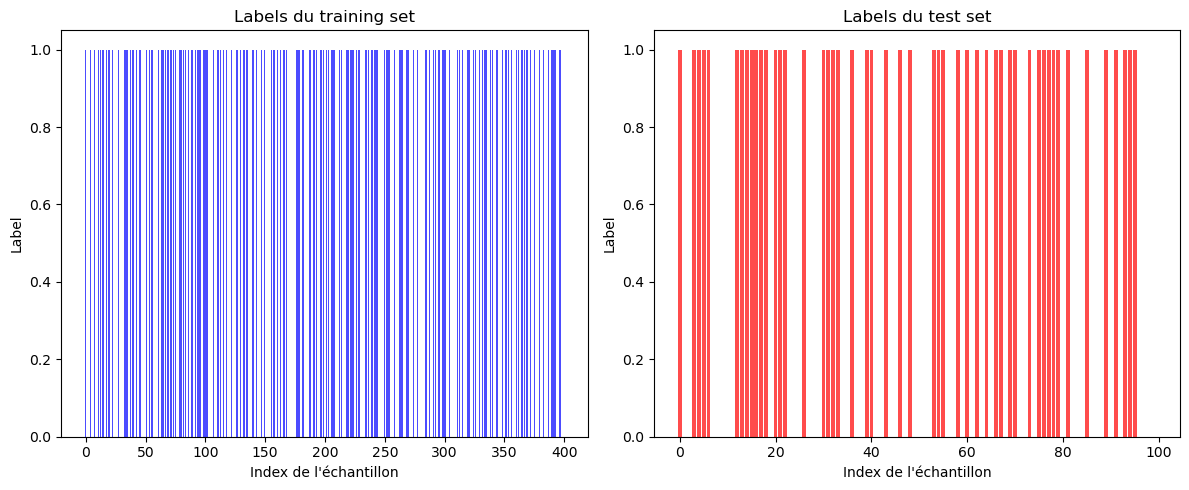

In [22]:
# Training et test set
X = X.reshape(X.shape[0], -1)  
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2, random_state=42,
                                                    shuffle=True, stratify=y)

# Nomalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# plot comment y est répartie (avant shuffle)
plt.figure(figsize=(6, 6))
plt.bar(range(len(y)), y +0.001,  color=['red' if label == 0 else 'blue' for label in y], alpha=0.7)
plt.title("Distribution des labels (0 = sans mémoire, 1 = avec mémoire)")
plt.xlabel("Index de l'échantillon")
plt.ylabel("Label")
plt.grid(False)
plt.tick_params(axis='x', which='both', bottom=True, top=True, direction='in')
plt.show()
# Plot de y_test et y_train
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(range(len(y_train)), y_train, color='blue', alpha=0.7)
plt.title("Labels du training set")
plt.xlabel("Index de l'échantillon")
plt.ylabel("Label")
plt.grid(False)
plt.subplot(1, 2, 2)
plt.bar(range(len(y_test)), y_test, color='red', alpha=0.7)
plt.title("Labels du test set")
plt.xlabel("Index de l'échantillon")
plt.ylabel("Label")
plt.grid(False)
plt.tight_layout()
plt.show()

In [ ]:
class_names = ["Memory", "No Memory"]
y_pred_dict = {}
proba_dict = {}
for name, clf in classifiers.items():
    clf.fit(X_train_scaled, y_train)
    y_pred_dict[name] = clf.predict(X_test_scaled)
    proba_dict[name] = clf.predict_proba(X_test_scaled)
    # Compute precision - recall - f1-score
    print(f"Classification report for {name}:\n")
    print(classification_report(y_test, y_pred, target_names=["No memory", "Memory included"]))
    print("\n")

    
#for name, clf in classifiers.items():
#    y_pred = y_pred_dict[name]
#    plot_learning_curve(clf, X_train_scaled, y_train, cv=5, scoring='accuracy', random_state=42, info_title=name)

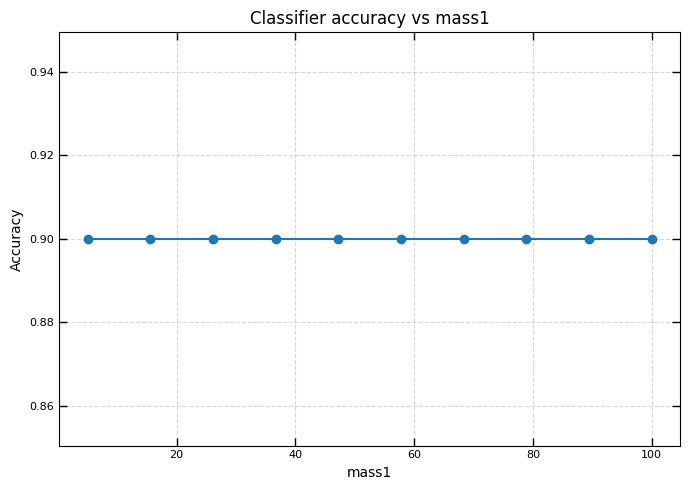

: 

: 

: 

: 

In [ ]:
#param_range = np.linspace(0, np.pi, 20)
#fixed_params = {'mass1' : 30, 'mass2': 30, 'distance': 100, 'delta_t': 1.0/4096, 'f_lower': 20.0, 't_c': 0.0}
#for name, clf in classifiers.items():   
#    plot_performance_vs_param('inclination', param_range, fixed_params, model='IMRPhenomD', classifier=clf, n_samples=25, info_title=name)

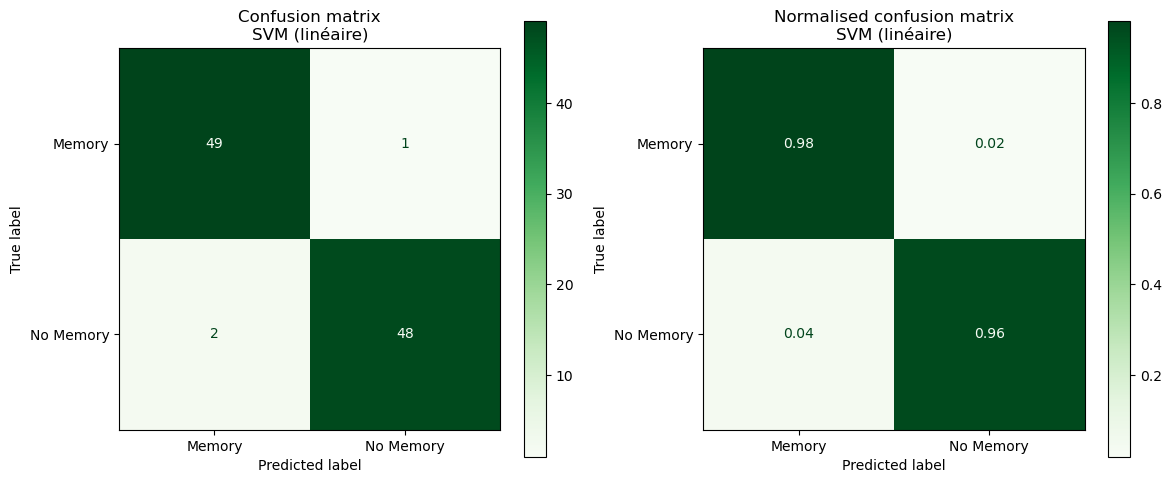

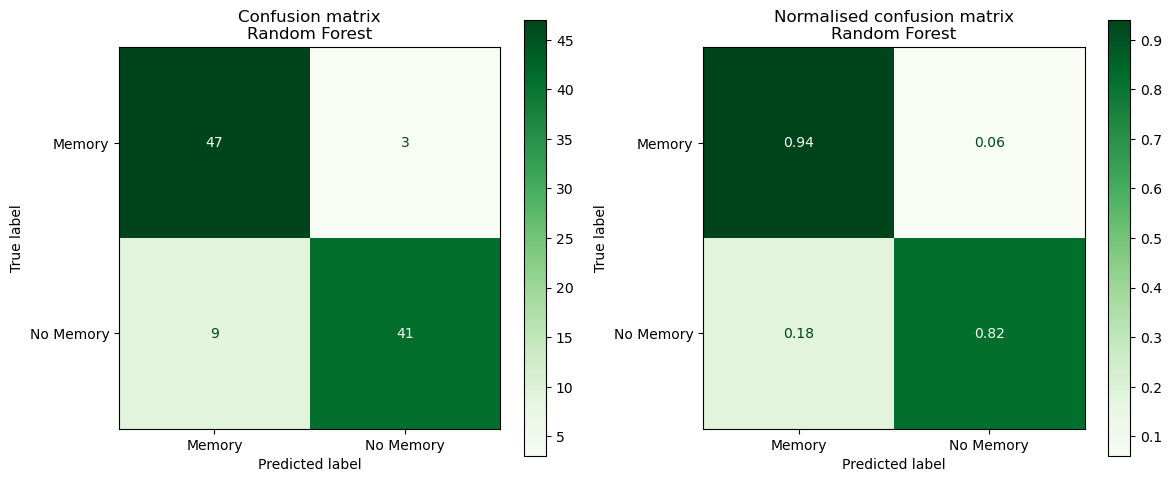

In [27]:
for name, clf in classifiers.items():
    y_pred = y_pred_dict[name]
    plot_confusion_matrices(y_test, y_pred, class_names=["Memory", "No Memory"], title=name)

Precision-Recall curve for SVM (linéaire)


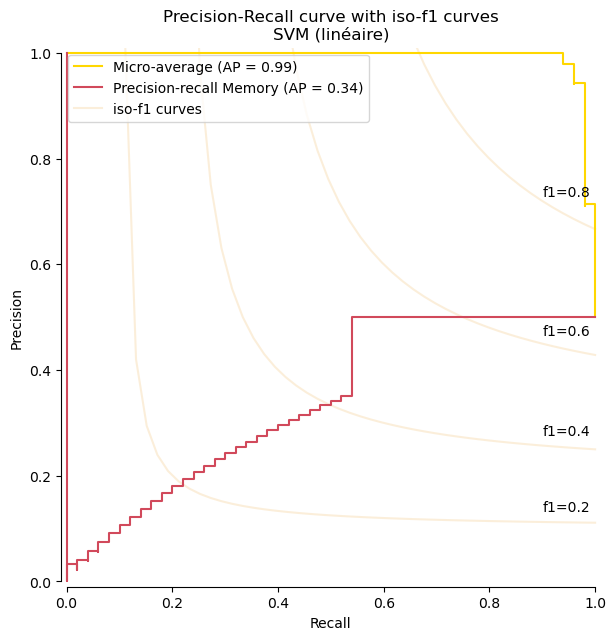

Precision-Recall curve for Random Forest


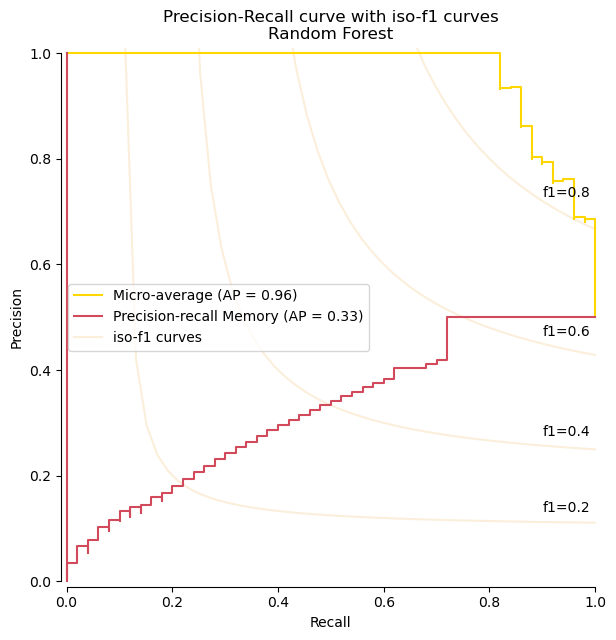

In [28]:
# Supposons que tu as déjà entraîné un classifieur, ex :
for name, clf in classifiers.items():
    print(f"Precision-Recall curve for {name}")
    y_score = proba_dict[name]
    plot_precision_recall_curves(y_test, y_score, class_names=["Memory", "No Memory"], classifier_name=name)

The **precision-recall curve** shows the *tradeoff between precision and recall* for different thresholds. A *high area under the curve* represents* both high recall and high precision*. High precision is achieved by having few false positives in the returned results, and high recall is achieved by having few false negatives in the relevant results. High scores for both show that the classifier is returning accurate results (high precision), as well as returning a majority of all relevant results (high recall).

**Average precision** (AP) summarizes such a plot as the weighted mean of precisions achieved at each threshold, with the increase in recall from the previous threshold used as the weight:

---

**A TESTER :**
* Appliquer méthodes de signal processing pour améliorer la qualité des données (filtrage, denoising, etc.)
* Entrainer les modèles sur : 
  * PSD 
  * Spectrogramme
  * Wavelet transform
* Comparer les scores obtenus pour chaque type de données (PSD, spectrogramme, wavelet transform) et discuter des résultats.
* Déterminer combien de donnée est nécessaire pour atteindre une performance satisfaisante du classificateur (en termes de précision, rappel, F1-score, etc.) et discuter de l'impact de la taille du dataset sur les résultats. Faire pareil pour les différentes méthodes (bruit gaussien, bruit réaliste, psd, ...) et discuter de l'impact du type de bruit sur les résultats.
* Figure score vs mass tot - distance - inclinaison - SNR - etc. pour les différentes méthodes (bruit gaussien, bruit réaliste, psd, spectrogramme, wavelet transform, etc.) et discuter de l'impact de ces paramètres sur les résultats.
* On peut pad la mémoire rendue par GWmemory pour regarder sur un temps plus long (ex : [-0.5 ; 0.5]s) et voir si cela améliore les résultats du classificateur (en particulier pour les méthodes basées sur la PSD, spectrogramme, wavelet transform, etc.).